In [102]:
%pip install mne

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [103]:
from pathlib import Path
import sys
import mne
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../src")

from eeg_project.data import load_subject_pair
from eeg_project.preprocessing import preprocess_raw, make_fixed_length_epochs

import importlib
import eeg_project.features
importlib.reload(eeg_project.features)
from eeg_project.features import extract_bandpower_features

import eeg_project.build_features
importlib.reload(eeg_project.build_features)
from eeg_project.build_features import build_features_for_all_subjects

# EDA

In [104]:
DATA_DIR = Path("../data/raw")

edf_files = sorted(DATA_DIR.rglob("*.edf"))
len(edf_files), edf_files[:5]

(72,
 [WindowsPath('../data/raw/Subject00_1.edf'),
  WindowsPath('../data/raw/Subject00_2.edf'),
  WindowsPath('../data/raw/Subject01_1.edf'),
  WindowsPath('../data/raw/Subject01_2.edf'),
  WindowsPath('../data/raw/Subject02_1.edf')])

In [105]:
info_files = list(DATA_DIR.rglob("subject-info.csv"))
info_files

[WindowsPath('../data/raw/subject-info.csv')]

In [106]:
subject_info = pd.read_csv(info_files[0])
subject_info.head()

,Subject,Age,Gender,Recording year,Number of subtractions,Count quality
0,Subject00,21,F,2011,9.70,0
1,Subject01,18,F,2011,29.35,1
2,Subject02,19,F,2012,12.88,1
3,Subject03,17,F,2010,31.00,1
4,Subject04,17,F,2010,8.60,0


In [107]:
rest_file = sorted(DATA_DIR.rglob("Subject00_1.edf"))[0]
task_file = sorted(DATA_DIR.rglob("Subject00_2.edf"))[0]

raw_rest = mne.io.read_raw_edf(rest_file, preload=True, verbose=False)
raw_task = mne.io.read_raw_edf(task_file, preload=True, verbose=False)

In [108]:
def clean_channel_names(raw):
    rename_dict = {}

    for ch_name in raw.ch_names:
        new_name = ch_name

        if new_name.startswith("EEG "):
            new_name = new_name.replace("EEG ", "")

        if new_name == "ECG ECG":
            new_name = "ECG"

        rename_dict[ch_name] = new_name

    return raw.copy().rename_channels(rename_dict)

In [109]:
raw_rest = clean_channel_names(raw_rest)
raw_task = clean_channel_names(raw_task)

raw_rest.ch_names

['Fp1',
 'Fp2',
 'F3',
 'F4',
 'F7',
 'F8',
 'T3',
 'T4',
 'C3',
 'C4',
 'T5',
 'T6',
 'P3',
 'P4',
 'O1',
 'O2',
 'Fz',
 'Cz',
 'Pz',
 'A2-A1',
 'ECG']

In [110]:
raw_rest.pick([ch for ch in raw_rest.ch_names if ch != "ECG"])
raw_task.pick([ch for ch in raw_task.ch_names if ch != "ECG"])

<RawEDF | Subject00_2.edf, 20 x 31000 (62.0 s), ~4.7 MiB, data loaded>

In [111]:
raw_rest.ch_names
len(raw_rest.ch_names)

20

In [112]:
montage = mne.channels.make_standard_montage("standard_1020")

raw_rest.set_montage(montage, on_missing="ignore")
raw_task.set_montage(montage, on_missing="ignore")

<RawEDF | Subject00_2.edf, 20 x 31000 (62.0 s), ~4.8 MiB, data loaded>

Effective window size : 4.096 (s)


Plotting power spectral density (dB=True).


c:\Users\yanoc\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


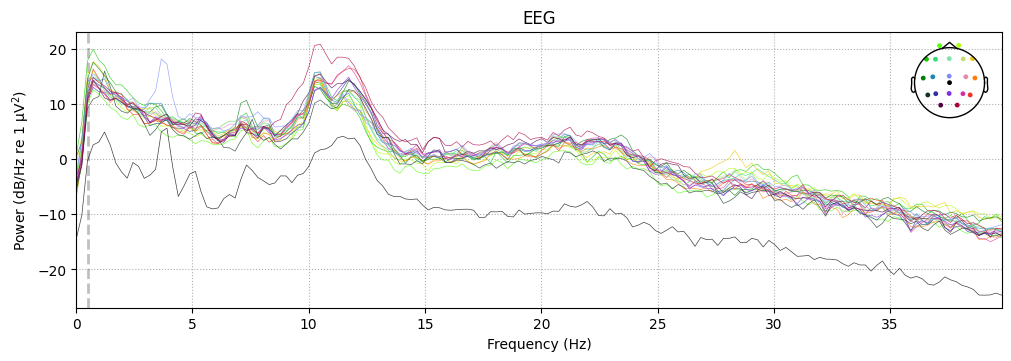

In [113]:
raw_rest.compute_psd(fmax=40).plot()

Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


c:\Users\yanoc\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


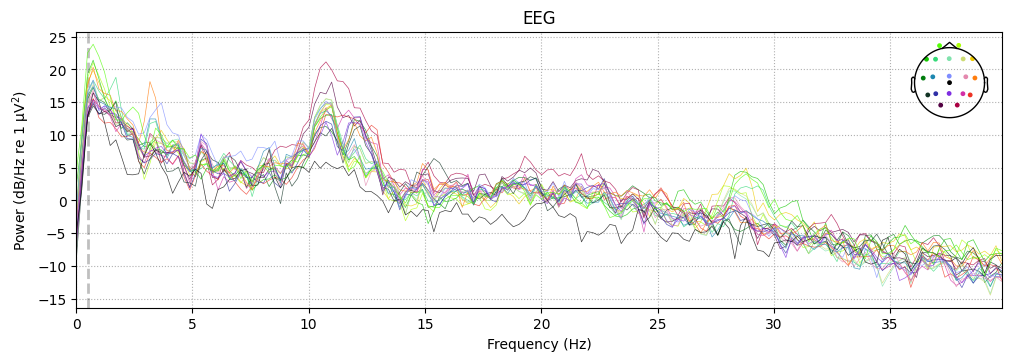

In [114]:
raw_task.compute_psd(fmax=40).plot()

In [115]:
psd_rest = raw_rest.compute_psd(fmin=1, fmax=40)
psd_task = raw_task.compute_psd(fmin=1, fmax=40)

Effective window size : 4.096 (s)
Effective window size : 4.096 (s)


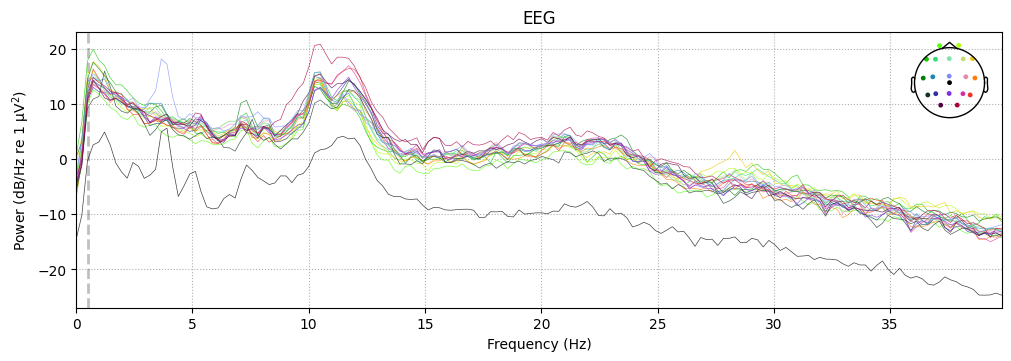

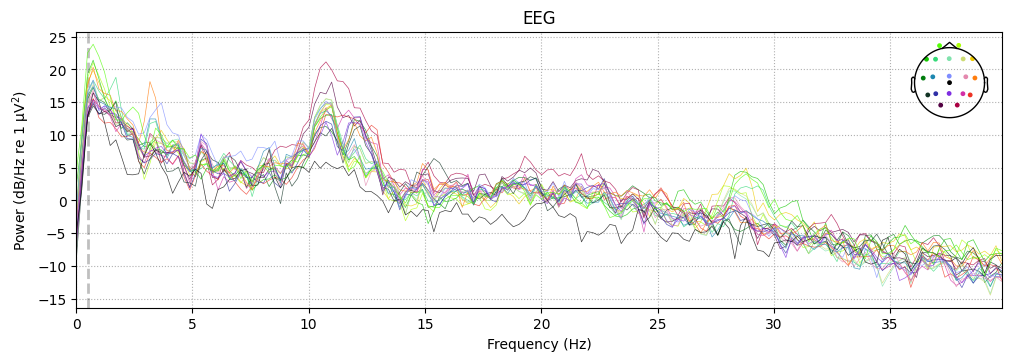

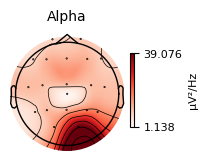

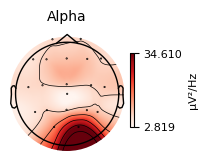

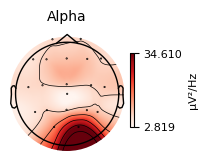

In [116]:
psd_rest.plot_topomap(bands={"Alpha": (8, 13)})
psd_task.plot_topomap(bands={"Alpha": (8, 13)})

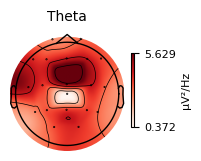

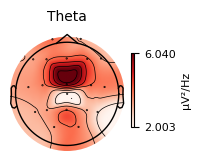

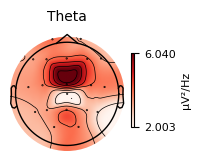

In [117]:
psd_rest.plot_topomap(bands={"Theta": (4, 8)})
psd_task.plot_topomap(bands={"Theta": (4, 8)})

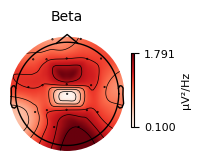

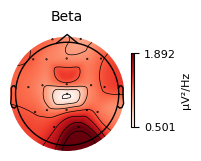

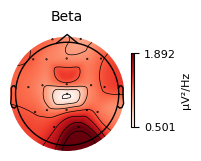

In [118]:
psd_rest.plot_topomap(bands={"Beta": (13, 30)})
psd_task.plot_topomap(bands={"Beta": (13, 30)})

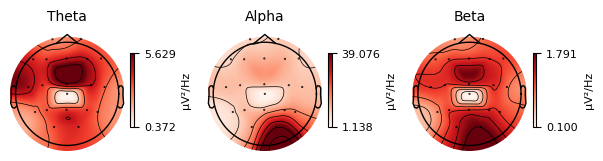

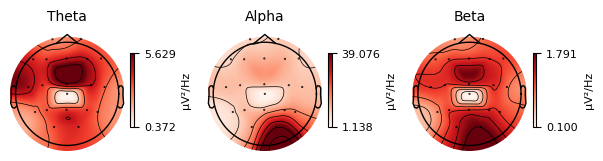

In [119]:
bands = {
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta": (13, 30),
}

psd_rest.plot_topomap(bands=bands)

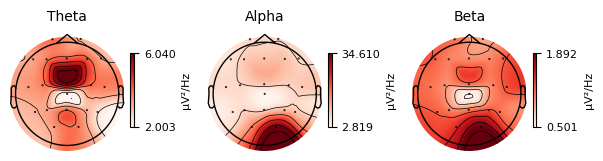

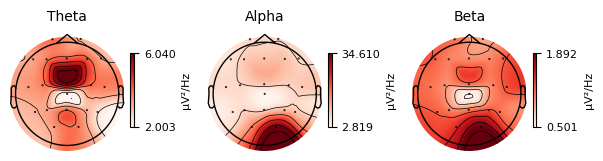

In [120]:
psd_task.plot_topomap(bands=bands)

In [121]:
DATA_DIR = Path("../data/raw")

raw_rest, raw_task = load_subject_pair(DATA_DIR, subject_id=0)

print(raw_rest.ch_names)
print(len(raw_rest.ch_names))
print(raw_rest.info["sfreq"])
print(raw_rest.times[-1])

['Fp1', 'Fp2', 'F3', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'C4', 'T5', 'T6', 'P3', 'P4', 'O1', 'O2', 'Fz', 'Cz', 'Pz', 'A2-A1']
20
500.0
181.998


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (3.302 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 

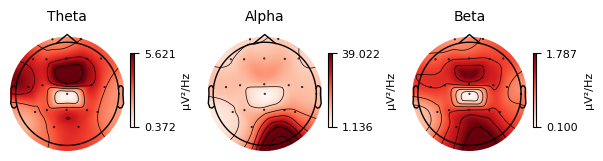

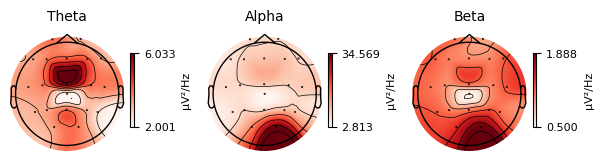

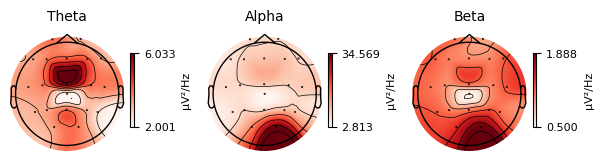

In [122]:
raw_rest, raw_task = load_subject_pair(DATA_DIR, subject_id=0)

raw_rest.filter(l_freq=1, h_freq=40)
raw_task.filter(l_freq=1, h_freq=40)

psd_rest = raw_rest.compute_psd(fmin=1, fmax=40)
psd_task = raw_task.compute_psd(fmin=1, fmax=40)

bands = {
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta": (13, 30),
}

psd_rest.plot_topomap(bands=bands)
psd_task.plot_topomap(bands=bands)

In [123]:
raw_rest, raw_task = load_subject_pair(DATA_DIR, subject_id=0)

print(raw_rest.ch_names)
print(len(raw_rest.ch_names))
print(raw_rest.info["sfreq"])

['Fp1', 'Fp2', 'F3', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'C4', 'T5', 'T6', 'P3', 'P4', 'O1', 'O2', 'Fz', 'Cz', 'Pz', 'A2-A1']
20
500.0


Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


c:\Users\yanoc\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
c:\Users\yanoc\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


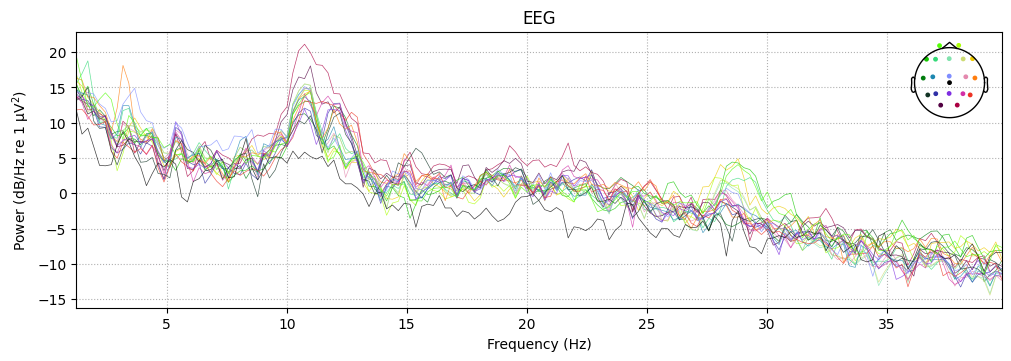

In [124]:
raw_rest_clean = preprocess_raw(raw_rest)
raw_task_clean = preprocess_raw(raw_task)

raw_rest_clean.compute_psd(fmin=1, fmax=40).plot()
raw_task_clean.compute_psd(fmin=1, fmax=40).plot()

In [125]:
epochs_rest = make_fixed_length_epochs(raw_rest_clean, duration=4.0)
epochs_task = make_fixed_length_epochs(raw_task_clean, duration=4.0)

print(epochs_rest)
print(epochs_task)

print(epochs_rest.get_data().shape)
print(epochs_task.get_data().shape)

<Epochs | 45 events (all good), 0 – 4 s (baseline off), ~13.8 MiB, data loaded,
 '1': 45>
<Epochs | 15 events (all good), 0 – 4 s (baseline off), ~4.6 MiB, data loaded,
 '1': 15>
(45, 20, 2001)
(15, 20, 2001)


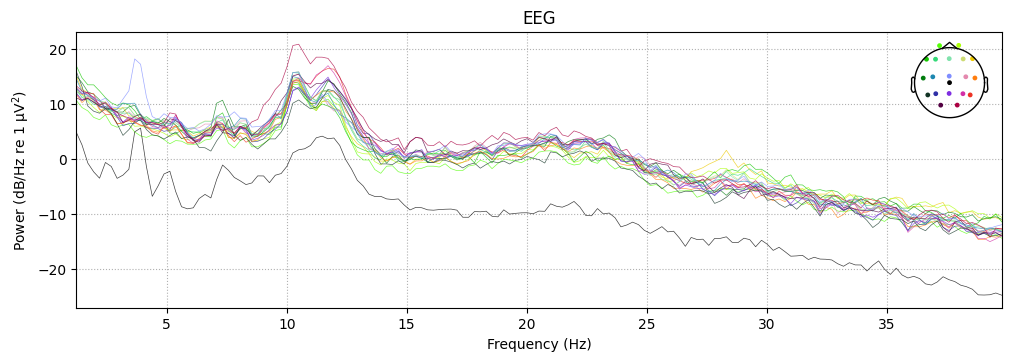

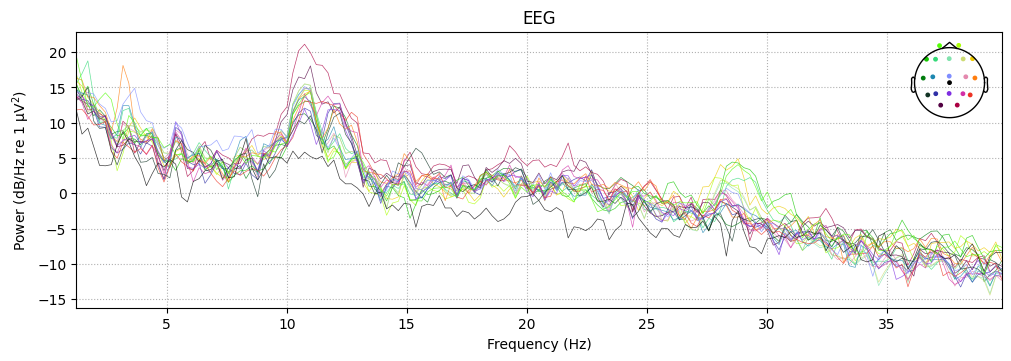

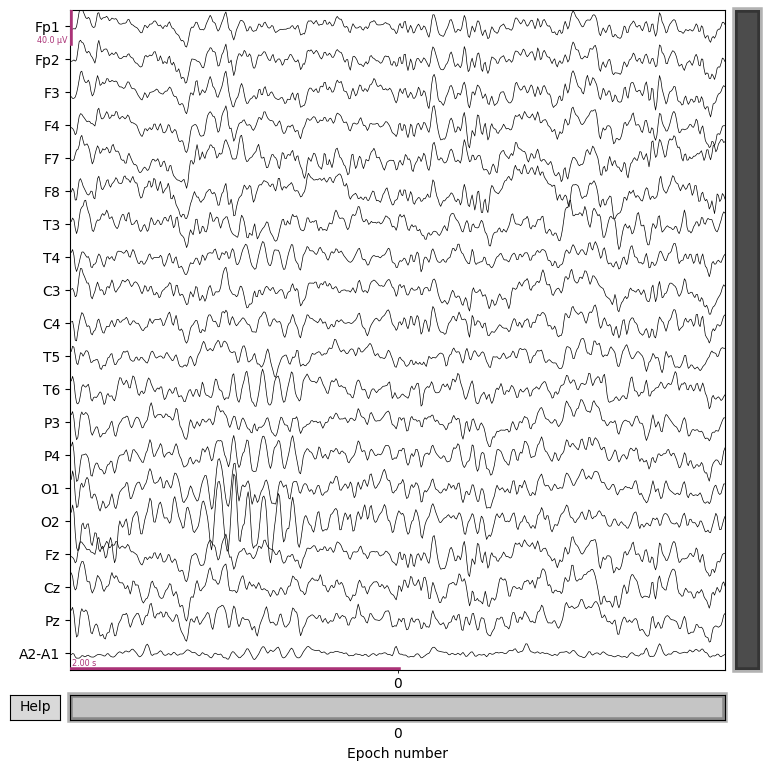

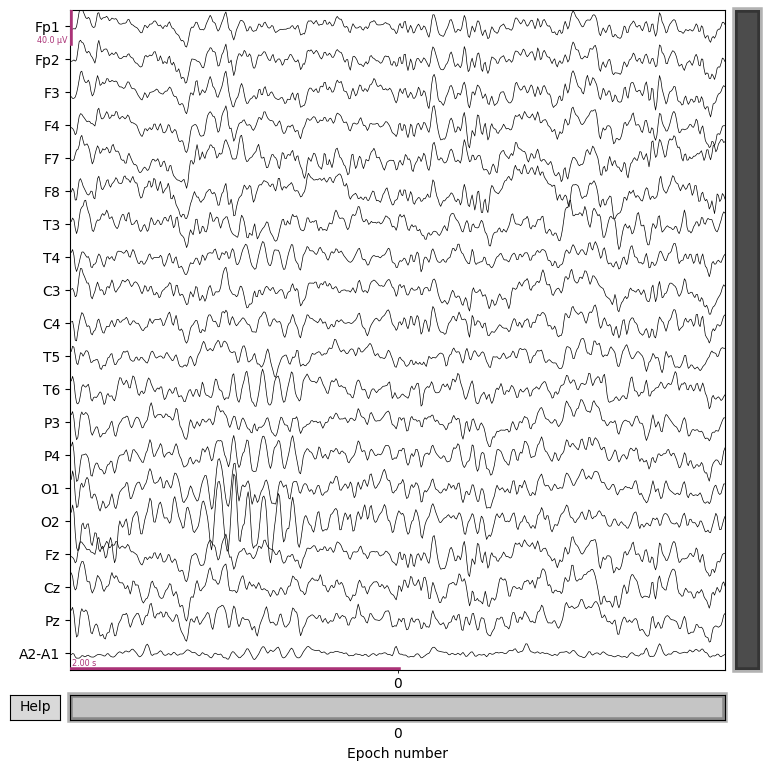

In [126]:
epochs_rest[0].plot()

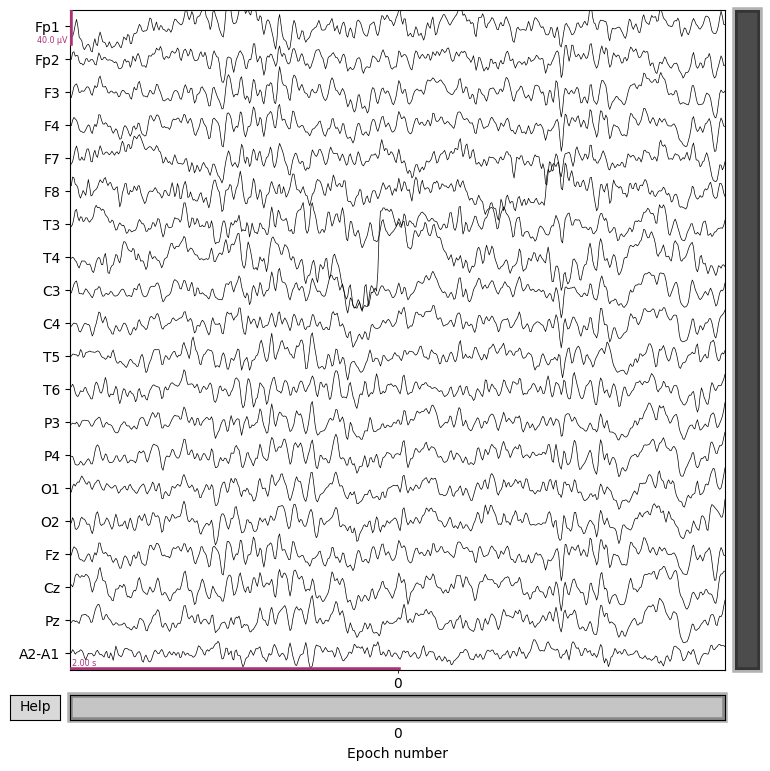

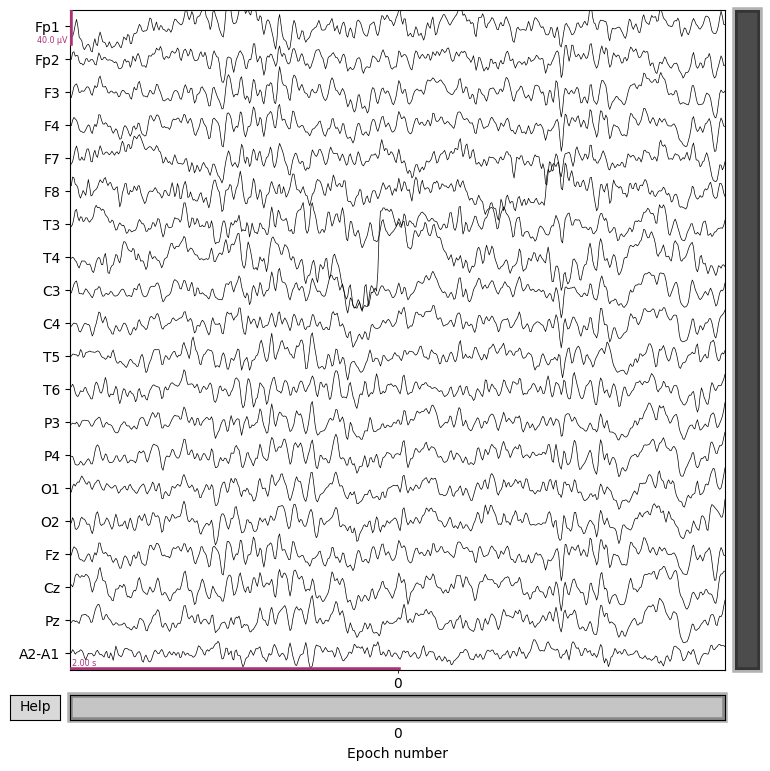

In [127]:
epochs_task[0].plot()

In [128]:
features_rest = extract_bandpower_features(
    epochs=epochs_rest,
    subject_id=0,
    condition="rest",
    label=0,
)

features_task = extract_bandpower_features(
    epochs=epochs_task,
    subject_id=0,
    condition="task",
    label=1,
)

features_subject0 = pd.concat([features_rest, features_task], ignore_index=True)

features_subject0.head()

,subject_id,epoch_id,condition,label,Fp1_delta_power,Fp1_theta_power,Fp1_alpha_power,Fp1_beta_power,Fp1_gamma_power,Fp2_delta_power,...,Pz_delta_power,Pz_theta_power,Pz_alpha_power,Pz_beta_power,Pz_gamma_power,A2-A1_delta_power,A2-A1_theta_power,A2-A1_alpha_power,A2-A1_beta_power,A2-A1_gamma_power
0,0,0,rest,0,1.421910e-11,6.356940e-12,1.365868e-11,6.813824e-12,9.893735e-13,1.945814e-11,...,2.632221e-11,1.275384e-11,1.749997e-11,9.798170e-12,8.603163e-13,2.538272e-12,1.553263e-12,3.466408e-12,1.259596e-12,9.015567e-14
1,0,1,rest,0,2.101086e-11,6.734573e-12,4.148139e-11,1.390338e-11,7.930928e-13,3.798183e-11,...,2.419394e-11,1.167185e-11,6.128612e-11,3.027920e-11,1.057576e-12,2.677821e-12,1.992063e-12,4.250301e-12,1.621739e-12,1.194406e-13
2,0,2,rest,0,1.604190e-11,5.418318e-12,3.790428e-11,1.083132e-11,7.706057e-13,2.372071e-11,...,1.672219e-11,6.126481e-12,1.085607e-10,2.604810e-11,9.167302e-13,2.166103e-12,1.355460e-12,3.411843e-12,2.220666e-12,1.180315e-13
3,0,3,rest,0,3.387004e-11,1.646096e-11,3.410443e-11,1.407096e-11,1.161959e-12,1.850285e-11,...,2.487964e-11,2.337150e-11,1.443865e-10,2.982391e-11,1.860601e-12,3.319556e-12,2.589488e-12,6.064304e-12,2.584858e-12,8.595979e-14
4,0,4,rest,0,9.776558e-12,6.242336e-12,6.672498e-11,1.000734e-11,9.903678e-13,1.512884e-11,...,2.380705e-11,3.256512e-11,5.567917e-11,2.349890e-11,1.029704e-12,3.182372e-12,1.482695e-12,5.735788e-12,1.286150e-12,1.526503e-13


In [129]:
features_subject0.shape

(60, 104)

In [130]:
features_subject0.head()

,subject_id,epoch_id,condition,label,Fp1_delta_power,Fp1_theta_power,Fp1_alpha_power,Fp1_beta_power,Fp1_gamma_power,Fp2_delta_power,...,Pz_delta_power,Pz_theta_power,Pz_alpha_power,Pz_beta_power,Pz_gamma_power,A2-A1_delta_power,A2-A1_theta_power,A2-A1_alpha_power,A2-A1_beta_power,A2-A1_gamma_power
0,0,0,rest,0,1.421910e-11,6.356940e-12,1.365868e-11,6.813824e-12,9.893735e-13,1.945814e-11,...,2.632221e-11,1.275384e-11,1.749997e-11,9.798170e-12,8.603163e-13,2.538272e-12,1.553263e-12,3.466408e-12,1.259596e-12,9.015567e-14
1,0,1,rest,0,2.101086e-11,6.734573e-12,4.148139e-11,1.390338e-11,7.930928e-13,3.798183e-11,...,2.419394e-11,1.167185e-11,6.128612e-11,3.027920e-11,1.057576e-12,2.677821e-12,1.992063e-12,4.250301e-12,1.621739e-12,1.194406e-13
2,0,2,rest,0,1.604190e-11,5.418318e-12,3.790428e-11,1.083132e-11,7.706057e-13,2.372071e-11,...,1.672219e-11,6.126481e-12,1.085607e-10,2.604810e-11,9.167302e-13,2.166103e-12,1.355460e-12,3.411843e-12,2.220666e-12,1.180315e-13
3,0,3,rest,0,3.387004e-11,1.646096e-11,3.410443e-11,1.407096e-11,1.161959e-12,1.850285e-11,...,2.487964e-11,2.337150e-11,1.443865e-10,2.982391e-11,1.860601e-12,3.319556e-12,2.589488e-12,6.064304e-12,2.584858e-12,8.595979e-14
4,0,4,rest,0,9.776558e-12,6.242336e-12,6.672498e-11,1.000734e-11,9.903678e-13,1.512884e-11,...,2.380705e-11,3.256512e-11,5.567917e-11,2.349890e-11,1.029704e-12,3.182372e-12,1.482695e-12,5.735788e-12,1.286150e-12,1.526503e-13


In [131]:
features_subject0.isna().sum().sum()

np.int64(0)

In [132]:
features_subject0[["condition", "label"]].value_counts()

condition  label
rest       0        45
task       1        15
Name: count, dtype: int64

In [133]:
features_subject0.to_csv("../data/processed/subject00_bandpower_features.csv", index=False)

In [134]:
features_small = build_features_for_all_subjects(
    data_dir="../data/raw",
    subject_ids=[0, 1, 2],
    epoch_duration=4.0,
)

features_small.shape

Processing subject 00...
Processing subject 01...
Processing subject 02...


(180, 104)

In [135]:
features_small[["condition", "label"]].value_counts()

condition  label
rest       0        135
task       1         45
Name: count, dtype: int64

In [136]:
features_small.isna().sum().sum()

np.int64(0)

In [137]:
features_small["subject_id"].value_counts().sort_index()

subject_id
0    60
1    60
2    60
Name: count, dtype: int64

# Запускаем на всех

In [138]:
features_all = build_features_for_all_subjects(
    data_dir="../data/raw",
    subject_ids=list(range(36)),
    epoch_duration=4.0,
)

features_all.shape

Processing subject 00...
Processing subject 01...
Processing subject 02...
Processing subject 03...
Processing subject 04...
Processing subject 05...
Processing subject 06...
Processing subject 07...
Processing subject 08...
Processing subject 09...
Processing subject 10...
Processing subject 11...
Processing subject 12...
Processing subject 13...
Processing subject 14...
Processing subject 15...
Processing subject 16...
Processing subject 17...
Processing subject 18...
Processing subject 19...
Processing subject 20...
Processing subject 21...
Processing subject 22...
Processing subject 23...
Processing subject 24...
Processing subject 25...
Processing subject 26...
Processing subject 27...
Processing subject 28...
Processing subject 29...
Processing subject 30...
Processing subject 31...
Processing subject 32...
Processing subject 33...
Processing subject 34...
Processing subject 35...


(2132, 104)

In [139]:
features_all[["condition", "label"]].value_counts()

condition  label
rest       0        1592
task       1         540
Name: count, dtype: int64

In [140]:
features_all["subject_id"].value_counts().sort_index()

subject_id
0     60
1     60
2     60
3     60
4     57
5     60
6     60
7     60
8     60
9     60
10    61
11    60
12    60
13    60
14    60
15    60
16    60
17    60
18    60
19    60
20    60
21    60
22    60
23    60
24    60
25    60
26    60
27    60
28    60
29    60
30    60
31    34
32    60
33    60
34    60
35    60
Name: count, dtype: int64

In [141]:
features_all.isna().sum().sum()

np.int64(0)

In [142]:
features_all.to_csv(
    "../data/processed/eegmat_bandpower_features_4s.csv",
    index=False,
)